In [1]:
import kuzu
from faker import Faker
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import random
from datetime import datetime, timedelta
import uuid

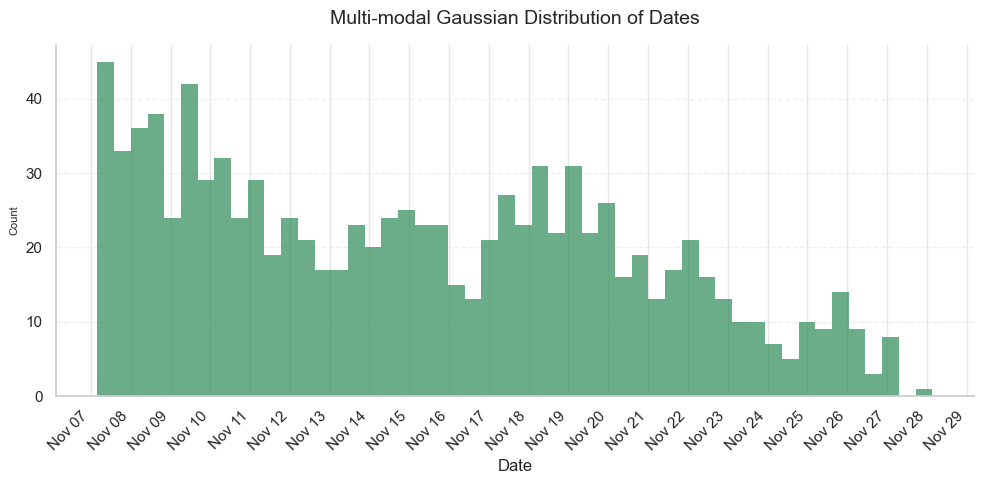

In [13]:
start_baseline = np.datetime64('2008-01-01')

# Define means as dates
mean_dates = np.array(['2009-03-12', '2014-06-15', '2019-10-01', '2024-08-20'], dtype='datetime64[D]')

# Convert means and baseline to numerical days since the Unix epoch
baseline_days = start_baseline.astype(int)
means_days = mean_dates.astype(int)

stds = [365*2, 365*2, 365*2, 365*2] # Distribution
weights = [0.3, 0.25, 0.3, 0.15]
n_samples = 1000

choices = np.random.choice(len(weights), size=n_samples, p=weights)

samples = np.zeros(n_samples)
for i in range(len(weights)):
    indices = np.where(choices == i)[0]
    n_mode_samples = len(indices)

    # Draw initial samples for this mode
    mode_samples = np.random.normal(loc=means_days[i], scale=stds[i], size=n_mode_samples)

    # Rejection loop: replace any values <= 0
    while True:
        invalid = mode_samples <= baseline_days
        n_invalid = np.sum(invalid)
        if n_invalid == 0:
            break
        # Redraw only the invalid samples
        mode_samples[invalid] = np.random.normal(loc=means_days[i], scale=stds[i], size=n_invalid)

    samples[indices] = mode_samples

generated_dates = samples.astype('datetime64[D]')

# 4. Clean and Scannable Plot
fig, ax = plt.subplots(figsize=(10, 5))

# REDUCED BINS & REMOVED EDGECOLOR: Creates a smoother visual look
ax.hist(generated_dates, bins=50, alpha=0.7, color='seagreen', edgecolor='none')

# SPARSITY CONTROLS: Show labels every 2 months instead of every month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
# FIX: Automatically rotate and right-align date labels
fig.autofmt_xdate(rotation=45)

# Clean up axes styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3) # Subtle background grid

plt.title('Multi-modal Gaussian Distribution of Dates', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=8)

plt.tight_layout()
plt.show()

In [3]:
industry_prefixes = {
    "Technology": 100, "Healthcare": 200, "Finance": 300,
    "Retail": 400, "Manufacturing": 500, "Real Estate": 600,
    "Entertainment": 700, "Education": 800, "Telecommunications": 900
}
industry_names = list(industry_prefixes.keys())

industry_size_weights = {
    "Technology": 1.3, "Healthcare": 1.4, "Finance": 1.5,
    "Retail": 1.0, "Manufacturing": 2, "Real Estate": 1.1,
    "Entertainment": 0.9, "Education": 0.7, "Telecommunications": 1.3
}

assigned_industries = []
assigned_sizes = []

era_2013 = np.datetime64('2013-01-01').astype(int)
era_2019 = np.datetime64('2019-01-01').astype(int)
era_2023 = np.datetime64('2023-01-01').astype(int)

for day in samples:
    if day < era_2013:
        probs = [0.05, 0.10, 0.35, 0.10, 0.25, 0.10, 0.02, 0.01, 0.02]
        era_size_modifier = 1.2
        target_industry_boost = "Finance"

    elif day < era_2019:
        probs = [0.40, 0.05, 0.05, 0.15, 0.05, 0.05, 0.15, 0.05, 0.05]
        era_size_modifier = 1.4
        target_industry_boost = "Technology"

    elif day < era_2023:
        probs = [0.15, 0.35, 0.05, 0.05, 0.05, 0.02, 0.10, 0.08, 0.15]
        era_size_modifier = 1.0
        target_industry_boost = "Healthcare"

    else:
        probs = [0.25, 0.15, 0.10, 0.15, 0.05, 0.05, 0.10, 0.10, 0.05]
        era_size_modifier = 0.6
        target_industry_boost = "Technology"

    ind = np.random.choice(industry_names, p=probs)
    assigned_industries.append(ind)

    base_industry_weight = industry_size_weights[ind]

    boost = 1.7 if ind == target_industry_boost else 1.0

    log_base = np.random.lognormal(mean=1.8, sigma=0.8)

    final_size = int(log_base * base_industry_weight * era_size_modifier * boost) + 5
    assigned_sizes.append(final_size)

assigned_industries = np.array(assigned_industries)
assigned_sizes = np.array(assigned_sizes)

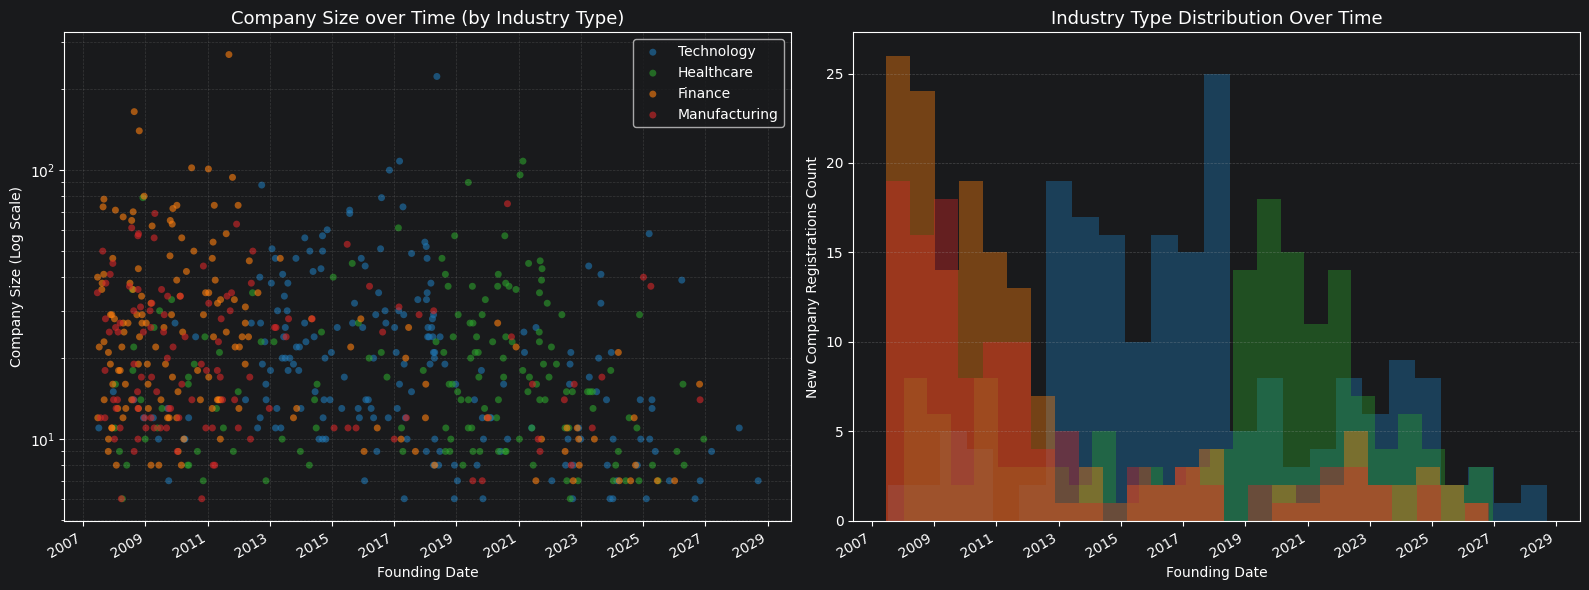

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

color_map = {
    "Technology": "#1f77b4", "Healthcare": "#2ca02c",
    "Finance": "#ff7f0e", "Manufacturing": "#d62728"
}

for ind in color_map.keys():
    mask = assigned_industries == ind
    ax1.scatter(generated_dates[mask], assigned_sizes[mask],
                color=color_map[ind], alpha=0.6, label=ind, s=25, edgecolors='none')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_yscale('log')
ax1.set_title('Company Size over Time (by Industry Type)', fontsize=13)
ax1.set_xlabel('Founding Date')
ax1.set_ylabel('Company Size (Log Scale)')
ax1.grid(True, which="both", linestyle='--', alpha=0.2)
ax1.legend()

for ind in color_map.keys():
    mask = assigned_industries == ind
    ax2.hist(generated_dates[mask], bins=25, alpha=0.4, label=ind, color=color_map[ind], edgecolor='none')

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('Industry Type Distribution Over Time', fontsize=13)
ax2.set_xlabel('Founding Date')
ax2.set_ylabel('New Company Registrations Count')
ax2.grid(axis='y', linestyle='--', alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:
cities = [
    "New York City", "Chicago", "San Francisco", "Austin", "Los Angeles",
    "Boston", "Seattle", "Houston", "Atlanta", "Miami"
]

states = {
    "New York City": "New York",
    "Chicago": "Illinois",
    "San Francisco": "California",
    "Austin": "Texas",
    "Los Angeles": "California",
    "Boston": "Massachusetts",
    "Seattle": "Washington",
    "Houston": "Texas",
    "Atlanta": "Georgia",
    "Miami": "Florida"
}

city_industry_weights = {
    "Technology": {"New York City": 0.15, "Chicago": 0.05, "San Francisco": 0.40, "Austin": 0.20, "Los Angeles": 0.10, "Boston": 0.05, "Seattle": 0.25, "Houston": 0.02, "Atlanta": 0.05, "Miami": 0.05},
    "Finance": {"New York City": 0.50, "Chicago": 0.25, "San Francisco": 0.10, "Austin": 0.05, "Los Angeles": 0.05, "Boston": 0.10, "Seattle": 0.02, "Houston": 0.03, "Atlanta": 0.05, "Miami": 0.15},
    "Healthcare": {"New York City": 0.10, "Chicago": 0.15, "San Francisco": 0.05, "Austin": 0.05, "Los Angeles": 0.10, "Boston": 0.35, "Seattle": 0.05, "Houston": 0.10, "Atlanta": 0.10, "Miami": 0.05},
    "Retail": {"New York City": 0.25, "Chicago": 0.15, "San Francisco": 0.05, "Austin": 0.10, "Los Angeles": 0.15, "Boston": 0.05, "Seattle": 0.15, "Houston": 0.10, "Atlanta": 0.15, "Miami": 0.10},
    "Manufacturing": {"New York City": 0.02, "Chicago": 0.30, "San Francisco": 0.02, "Austin": 0.05, "Los Angeles": 0.10, "Boston": 0.05, "Seattle": 0.10, "Houston": 0.25, "Atlanta": 0.10, "Miami": 0.02},
    "Real Estate": {"New York City": 0.30, "Chicago": 0.10, "San Francisco": 0.10, "Austin": 0.10, "Los Angeles": 0.20, "Boston": 0.05, "Seattle": 0.05, "Houston": 0.05, "Atlanta": 0.05, "Miami": 0.25},
    "Entertainment": {"New York City": 0.25, "Chicago": 0.05, "San Francisco": 0.05, "Austin": 0.05, "Los Angeles": 0.55, "Boston": 0.02, "Seattle": 0.02, "Houston": 0.02, "Atlanta": 0.10, "Miami": 0.15},
    "Education": {"New York City": 0.20, "Chicago": 0.15, "San Francisco": 0.10, "Austin": 0.10, "Los Angeles": 0.15, "Boston": 0.40, "Seattle": 0.05, "Houston": 0.05, "Atlanta": 0.10, "Miami": 0.10},
    "Telecommunications": {"New York City": 0.20, "Chicago": 0.15, "San Francisco": 0.10, "Austin": 0.15, "Los Angeles": 0.10, "Boston": 0.05, "Seattle": 0.05, "Houston": 0.10, "Atlanta": 0.25, "Miami": 0.05}
}

city_size_weights = {
    "New York City": 1.5, "Los Angeles": 1.4, "Chicago": 1.2,
    "San Francisco": 1.1, "Houston": 1.0, "Atlanta": 0.9,
    "Boston": 0.9, "Seattle": 0.9, "Austin": 0.8, "Miami": 0.8
}

assigned_cities = []

# 4. Loop through generated companies to assign a city based on combined probabilities
for ind, size in zip(assigned_industries, assigned_sizes):
    probs = []

    for city in cities:
        # Fetch the industry preference for this city
        ind_weight = city_industry_weights[ind][city]

        # Fetch the size preference for this city
        size_weight = city_size_weights[city]

        # Scaling factor: The larger the company, the heavier the city's size weight matters
        # Using a log scale on size ensures massive sizes don't completely break the distribution
        size_effect = np.log1p(size) * size_weight

        # Combine the industry preference and the size effect
        combined_score = ind_weight * size_effect
        probs.append(combined_score)

    # Normalize scores into a valid probability distribution (sum to 1.0)
    probs = np.array(probs)
    probs /= probs.sum()

    # Randomly select a city using the unique probabilities of this company
    chosen_city = np.random.choice(cities, p=probs)
    assigned_cities.append(chosen_city)

assigned_cities = np.array(assigned_cities)

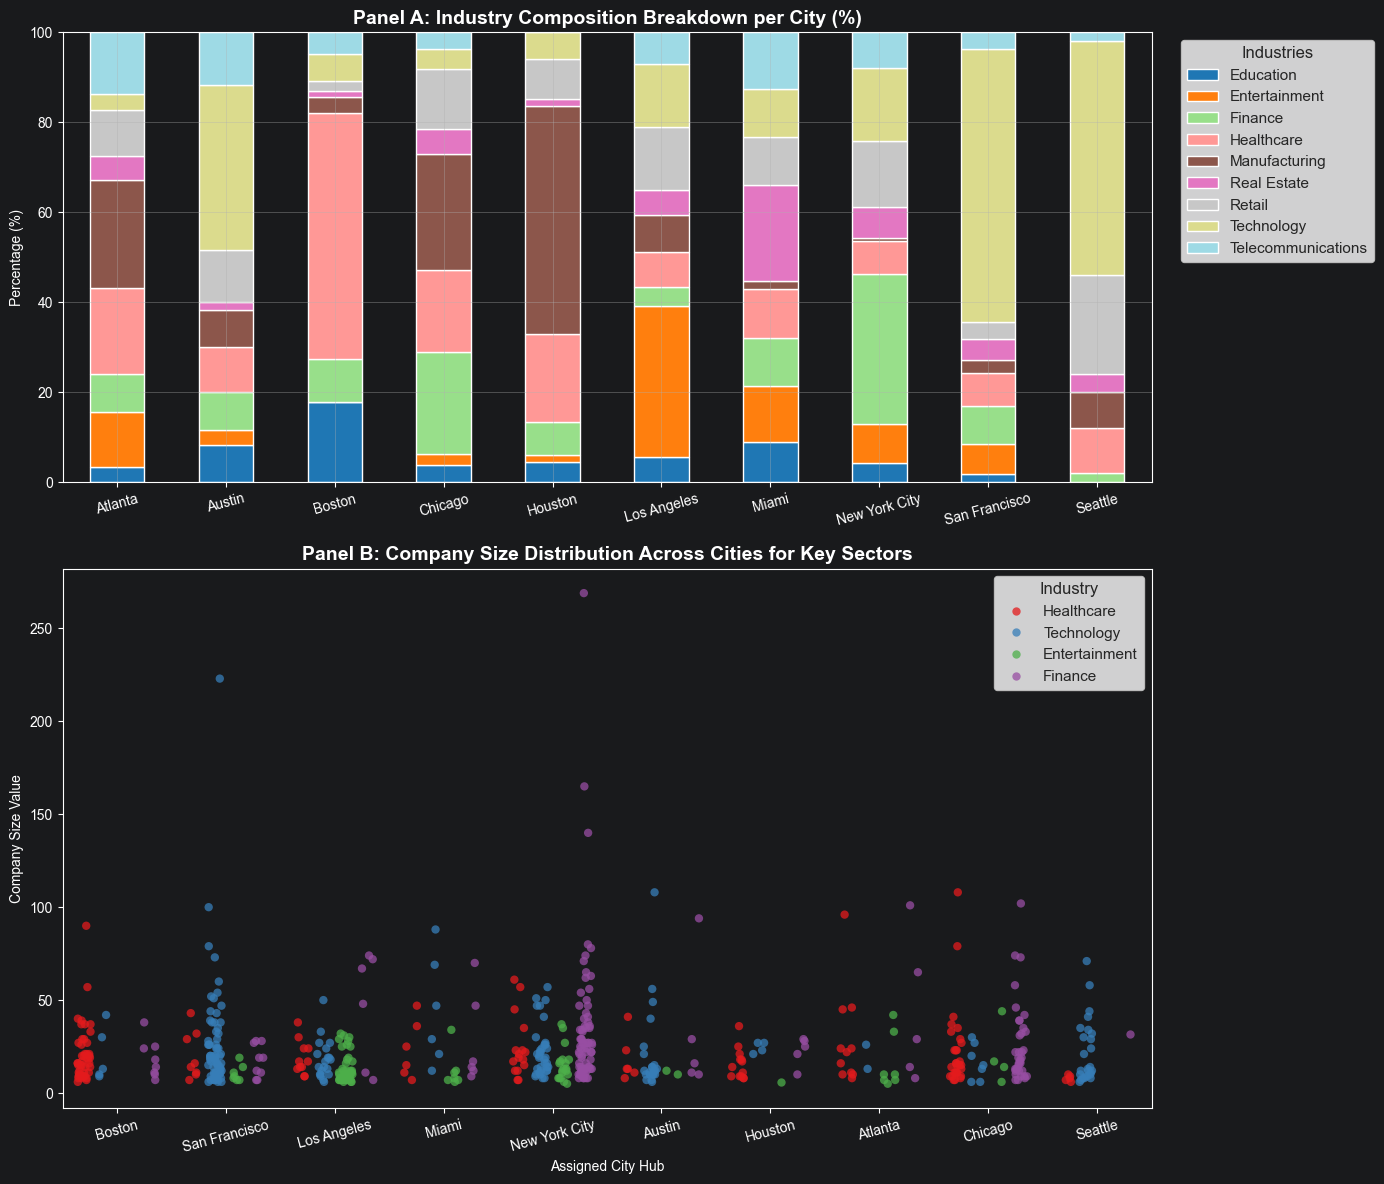

In [6]:

df = pd.DataFrame({
    "Date": generated_dates,
    "Industry": assigned_industries,
    "Size": assigned_sizes,
    "City": assigned_cities
})

# 2. Set up a 2-panel visualization dashboard
fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1.2]})
sns.set_theme(style="whitegrid")

# PANEL A: Industry Distribution by City (Verification of Type Clumping)
# Create a cross-tabulation table normalized by row to display percentages
city_industry_pct = pd.crosstab(df['City'], df['Industry'], normalize='index') * 100

city_industry_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='tab20'
)
axes[0].set_title("Panel A: Industry Composition Breakdown per City (%)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title="Industries", bbox_to_anchor=(1.02, 1), loc='upper left')

# PANEL B: Company Size Distribution by City & Industry (Verification of Size + Type Clumping)
# Filter for key illustrative industries to keep the plot highly scannable
target_industries = ["Technology", "Finance", "Healthcare", "Entertainment"]
df_filtered = df[df['Industry'].isin(target_industries)]

sns.stripplot(
    data=df_filtered,
    x="City",
    y="Size",
    hue="Industry",
    jitter=0.25,
    size=6,
    alpha=0.75,
    palette="Set1",
    dodge=True,
    ax=axes[1]
)
axes[1].set_title("Panel B: Company Size Distribution Across Cities for Key Sectors", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Company Size Value")
axes[1].set_xlabel("Assigned City Hub")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [7]:
locales = {
    'en_US': 0.7,
    'en_GB': 0.2,
    'en_IN': 0.1
}

fake = Faker(locales)

def random_gaussian_in_range(mean, std, low, high):
    while True:
        sample = random.gauss(mean, std)
        if low <= sample <= high:
            return sample

categories = ["American", "Indian", "British", "Mexican"]

probabilities = [0.85, 0.03, 0.02, 0.10]

In [8]:
from df_types import *

# Initialize empty lists for Nodes
nodes_company = []
nodes_person = []
nodes_address = []
nodes_device = []
nodes_account = []
nodes_document = []
nodes_watchlist_entity = []

# Initialize empty lists for Relationships
rel_works_for = []
rel_directs = []
rel_company_has_address = []
rel_person_has_address = []
rel_company_uses_device = []
rel_person_uses_device = []
rel_company_owns_account = []
rel_person_owns_account = []
rel_company_provided_doc = []
rel_person_provided_doc = []
rel_person_owns_equity = [] # <--- NEW EQUITY LIST
rel_company_owns_equity = []
rel_company_matches_watchlist = []
rel_person_matches_watchlist = []

# (Placeholders for later generation)
# rel_matches_watchlist = []
# rel_sent_tx = []
# rel_recieved_tx = []

# Helper lists for random generation
device_types = ["Mobile", "Desktop", "Tablet"]
os_types = ["iOS", "Android", "Windows", "macOS", "Linux"]
account_types = ["Checking", "Savings", "Corporate"]
doc_types_person = ["Passport", "Driver License", "National ID"]
doc_types_company = ["Articles of Incorporation", "Tax Certificate", "Business License"]

# Baseline year to calculate company age
CURRENT_YEAR = 2026

In [9]:
# Start Generation Loop

num_watchlist_entities = 100
watchlist_ids = []
watchlist_lists = ["OFAC SDN", "Interpol Red Notice", "EU Sanctions", "UK HMT", "UN Security Council"]

for w in range(num_watchlist_entities):
    w_id = f"wl_{w}"
    watchlist_ids.append(w_id)
    nodes_watchlist_entity.append({
        "entityId": w_id,
        "listName": random.choice(watchlist_lists),
        "listType": random.choice(["Individual", "Entity"]),
        "addedDate": datetime(CURRENT_YEAR - random.randint(1, 15), random.randint(1, 12), random.randint(1, 28))
    })

# --- PRE-GENERATE VIRTUAL OFFICES ---
# Create 5 classic "Virtual Office" hubs (e.g., in Delaware or Wyoming)
num_virtual_offices = 5
virtual_offices = []
for v in range(num_virtual_offices):
    v_id = f"addr_vo_{v}"
    virtual_offices.append({
        "addressId": v_id,
        "street": fake.street_address().replace('\n', ', ').replace("\"", "") + f" Suite {random.randint(100,999)}",
        "city": "Wilmington",
        "state": "Delaware",
        "zipCode": fake.zipcode(),
        "country": "USA"
    })
    nodes_address.append(virtual_offices[-1]) # Add them to the global nodes list

# --- PRE-GENERATE PROFESSIONAL NOMINEES ---
num_nominees = 3
nominee_ids = []
for n in range(num_nominees):
    n_id = f"nominee_{n}"
    nominee_ids.append(n_id)
    nodes_person.append({
        "personId": n_id,
        "firstName": fake.first_name(),
        "lastName": fake.last_name(),
        "dob": datetime(1970 + n, 1, 1),
        "taxId": f"NOM_{n}",
        "nationality": "American",
        "pepStatus": False,
        "kycStatus": "True",
        "riskScore": 95.0 # Nominees are inherently high risk
    })

# --- NEW: Global Pools for Cross-Ownership ---
global_wealthy_individuals = []
global_holding_companies = []
global_employees = []

# Realistic KYC Distributions
kyc_states = ["Verified", "Pending", "Expired", "Rejected"]
kyc_weights_low_risk = [0.85, 0.10, 0.04, 0.01]
kyc_weights_high_risk = [0.40, 0.20, 0.20, 0.20]


In [10]:
for i in tqdm(range(len(df)), desc="Generating Companies and Data", colour="red"):
    c_id = f"c_{i}"
    inc_date = df["Date"].iloc[i]
    ind_code = str(industry_prefixes[df["Industry"].iloc[i]])

    age_in_years = max(0, CURRENT_YEAR - inc_date.year)

    # ==========================================
    # 1. COMPANY GENERATION
    # ==========================================
    c_risk_base = random_gaussian_in_range(35, 50, 0, 100)
    c_kyc = random.choices(kyc_states, weights=kyc_weights_high_risk if c_risk_base > 75 else kyc_weights_low_risk, k=1)[0]

    nodes_company.append({
        "companyId": c_id,
        "name": fake.unique.company(),
        "regNumber": f"r{ind_code}{i}",
        "incorporationDate": inc_date,
        "industryCode": ind_code,
        "kycStatus": c_kyc,
        "riskScore": c_risk_base
    })

    # TYPOLOGY: Professional Nominee Director (Massive Star Graph)
    if random.random() < 0.02:
        nominee = random.choice(nominee_ids)
        rel_directs.append({"_from": nominee, "_to": c_id, "role": "Nominee Director", "appointedDate": inc_date})

    # Company Address (Virtual Office Typology)
    if random.random() < 0.05:
        c_addr_id = random.choice(virtual_offices)["addressId"]
    else:
        c_addr_id = f"addr_c_{i}"
        nodes_address.append({
            "addressId": c_addr_id,
            "street": fake.street_address().replace('\n', ', ').replace("\"", ""),
            "city": df["City"].iloc[i],
            "state": states[df["City"].iloc[i]],
            "zipCode": fake.zipcode(),
            "country": "USA"
        })
    rel_company_has_address.append({"_from": c_id, "_to": c_addr_id, "addressType": "Business", "isCurrent": True})

    # Company Device
    c_dev_id = f"dev_c_{i}"
    nodes_device.append({
        "deviceId": c_dev_id,
        "deviceType": random.choice(device_types),
        "os": random.choice(os_types),
        "ipAddress": fake.ipv4(),
        "macAddress": fake.mac_address(),
        "isp": fake.company(),
        "registeredCountry": "USA"
    })
    rel_company_uses_device.append({"_from": c_id, "_to": c_dev_id, "firstSeen": inc_date, "lastSeen": inc_date, "trustScore": 90.0})

    # Company Account & Document
    c_acc_id = f"acc_c_{i}"
    nodes_account.append({
        "accountId": c_acc_id,
        "accountType": "Corporate",
        "balance": round(random.uniform(5000, 500000), 2),
        "currency": "USD",
        "status": "Active",
        "openedDate": inc_date,
        "branchCode": str(random.randint(1000, 9999))
    })
    rel_company_owns_account.append({"_from": c_id, "_to": c_acc_id, "role": "Primary Entity", "since": inc_date})

    c_doc_id = f"doc_c_{i}"
    nodes_document.append({
        "docId": c_doc_id,
        "docType": random.choice(doc_types_company),
        "issuedCountry": "USA",
        "expiryDate": inc_date + pd.Timedelta(days=365*5),
        "isForged": bool(random.random() < 0.01)
    })
    rel_company_provided_doc.append({"_from": c_id, "_to": c_doc_id, "submissionDate": inc_date, "verificationMethod": "Automated"})

    # Company Watchlist Match
    if random.random() < 0.15:
        wl_hit = random.choice(watchlist_ids)
        is_true_match = random.random() < 0.2
        rel_company_matches_watchlist.append({
            "_from": c_id, "_to": wl_hit,
            "similarityScore": round(random.uniform(0.95, 1.0) if is_true_match else random.uniform(0.75, 0.94), 2),
            "matchDate": inc_date,
            "status": "Confirmed" if is_true_match else "False Positive"
        })

    # ==========================================
    # 2. CORPORATE EQUITY & TYPOLOGIES
    # ==========================================
    if age_in_years > 5 and df["Size"].iloc[i] > 50 and random.random() < 0.1:
        global_holding_companies.append(c_id)

    equity_remaining = 100.0

    # TYPOLOGY: Corporate Subsidiary Layering
    if global_holding_companies and random.random() < 0.10:
        parent_company = random.choice(global_holding_companies)
        subsidiary_stake = random.choice([51.0, 100.0])

        rel_company_owns_equity.append({   # <--- USE THE NEW LIST HERE
            "_from": parent_company, "_to": c_id, "percentage": subsidiary_stake, "votingRights": subsidiary_stake
        })
        equity_remaining -= subsidiary_stake

    # TYPOLOGY: Cross-Ownership / Angel Investor
    if global_wealthy_individuals and equity_remaining > 10 and random.random() < 0.15:
        investor = random.choice(global_wealthy_individuals)
        investor_stake = round(random.uniform(5.0, min(20.0, equity_remaining)), 2)
        rel_person_owns_equity.append({
            "_from": investor, "_to": c_id, "percentage": investor_stake, "votingRights": investor_stake
        })
        equity_remaining -= investor_stake

    # ==========================================
    # 3. EMPLOYEES & FOUNDERS
    # ==========================================
    num_employees = int(df["Size"].iloc[i])
    is_ubo_evasion = (equity_remaining == 100.0) and (random.random() < 0.05)

    for j in range(num_employees):

        # TYPOLOGY: Cross-Employment / Ghost Employees
        if j > 0 and global_employees and random.random() < 0.03:
            moonlighter_id = random.choice(global_employees)
            rel_works_for.append({
                "_from": moonlighter_id, "_to": c_id,
                "jobTitle": "Consultant" if random.random() < 0.5 else fake.job(),
                "employmentType": random.choice(["Contractor", "Part-time"]),
                "startDate": inc_date,
                "salaryRange": str(random.randint(20000, 80000))
            })
            continue

        p_id = f"{i}w{j}R0"
        last_name = fake.last_name()
        primary_owns_equity = False

        age_at_inc = np.random.randint(22, 50)
        dob = datetime(inc_date.year - age_at_inc, np.random.randint(1, 13), np.random.randint(1, 28))

        p_risk = random_gaussian_in_range(45, 35, 0, 100)
        p_kyc = random.choices(kyc_states, weights=kyc_weights_high_risk if p_risk > 75 else kyc_weights_low_risk, k=1)[0]

        nodes_person.append({
            "personId": p_id,
            "firstName": fake.first_name(),
            "lastName": last_name,
            "dob": dob,
            "taxId": f"{p_id}T{ind_code}",
            "nationality": random.choices(categories, weights=probabilities, k=1)[0],
            "pepStatus": bool(random.random() < 0.07),
            "kycStatus": p_kyc,
            "riskScore": p_risk
        })

        if j > 0: global_employees.append(p_id)

        rel_works_for.append({
            "_from": p_id, "_to": c_id,
            "jobTitle": "Founder/CEO" if j == 0 else fake.job(),
            "employmentType": random.choice(["Full-time", "Contractor"]),
            "startDate": inc_date,
            "salaryRange": str(random.randint(40000, 150000))
        })

        # Founder Directs & Equity
        if j == 0:
            rel_directs.append({"_from": p_id, "_to": c_id, "role": "Director", "appointedDate": inc_date})

            if equity_remaining > 0:
                if is_ubo_evasion:
                    stake = 24.9
                    rel_person_owns_equity.append({"_from": p_id, "_to": c_id, "percentage": stake, "votingRights": stake})
                    equity_remaining -= stake
                    global_wealthy_individuals.append(p_id)
                    primary_owns_equity = True
                else:
                    base_equity_chance = min(0.80, 0.20 + (age_in_years * 0.05))
                    if random.random() < base_equity_chance:
                        stake = round(random.uniform(10.0, equity_remaining), 2)
                        rel_person_owns_equity.append({"_from": p_id, "_to": c_id, "percentage": stake, "votingRights": stake})
                        equity_remaining -= stake
                        primary_owns_equity = True
                        if stake > 20.0: global_wealthy_individuals.append(p_id)

        # Employee Address, Device, Account, Doc, Watchlist
        p_addr_id = f"addr_p_{i}_{j}"
        nodes_address.append({
            "addressId": p_addr_id, "street": fake.street_address().replace('\n', ', ').replace("\"", ""),
            "city": df["City"].iloc[i], "state": states[df["City"].iloc[i]], "zipCode": fake.zipcode(), "country": "USA"
        })
        rel_person_has_address.append({"_from": p_id, "_to": p_addr_id, "addressType": "Residential", "isCurrent": True})

        p_dev_id = f"dev_p_{i}_{j}"
        device_country = fake.country() if (p_risk > 75.0 and random.random() < 0.60) else "USA"
        nodes_device.append({
            "deviceId": p_dev_id, "deviceType": random.choice(["Mobile", "Desktop"]),
            "os": random.choices(os_types, weights=[0.28, 0.17, 0.25, 0.20, 0.10], k=1)[0],
            "ipAddress": fake.ipv4(), "macAddress": fake.mac_address(), "isp": fake.company(), "registeredCountry": device_country
        })
        rel_person_uses_device.append({"_from": p_id, "_to": p_dev_id, "firstSeen": inc_date, "lastSeen": inc_date, "trustScore": 85.0})

        p_acc_id = f"acc_p_{i}_{j}"
        nodes_account.append({
            "accountId": p_acc_id, "accountType": random.choice(["Checking", "Savings"]),
            "balance": round(random.uniform(100, 25000), 2), "currency": "USD", "status": "Active",
            "openedDate": inc_date, "branchCode": str(random.randint(1000, 9999))
        })
        rel_person_owns_account.append({"_from": p_id, "_to": p_acc_id, "role": "Owner", "since": inc_date})

        p_doc_id = f"doc_p_{i}_{j}"
        nodes_document.append({
            "docId": p_doc_id, "docType": random.choice(doc_types_person), "issuedCountry": "USA",
            "expiryDate": inc_date + pd.Timedelta(days=365*4), "isForged": bool(random.random() < 0.05)
        })
        rel_person_provided_doc.append({"_from": p_id, "_to": p_doc_id, "submissionDate": inc_date, "verificationMethod": "Manual"})

        if random.random() < (0.20 if p_risk > 80 else 0.03):
            wl_hit = random.choice(watchlist_ids)
            is_true_match = random.random() < 0.15
            rel_person_matches_watchlist.append({
                "_from": p_id, "_to": wl_hit,
                "similarityScore": round(random.uniform(0.95, 1.0) if is_true_match else random.uniform(0.75, 0.94), 2),
                "matchDate": inc_date, "status": "Confirmed" if is_true_match else "False Positive"
            })

        # ==========================================
        # 4. RELATIVES
        # ==========================================
        num_relatives = 3 if (j == 0 and is_ubo_evasion) else np.random.randint(0, 4)

        for k in range(1, num_relatives + 1):
            rp_id = f"{i}w{j}R{k}"
            is_ubo_relative = (j == 0 and is_ubo_evasion)

            nodes_person.append({
                "personId": rp_id, "firstName": fake.first_name(), "lastName": last_name,
                "dob": datetime(dob.year + np.random.randint(-5, 5), np.random.randint(1, 13), np.random.randint(1, 28)),
                "taxId": f"{rp_id}I{ind_code}", "nationality": random.choices(categories, weights=probabilities, k=1)[0],
                "pepStatus": bool(random.random() < 0.07),
                "kycStatus": "Pending" if is_ubo_relative else random.choices(kyc_states, weights=kyc_weights_low_risk, k=1)[0],
                "riskScore": 85.0 if is_ubo_relative else random_gaussian_in_range(45, 35, 0, 100)
            })

            # Relative Equity Allocation
            if is_ubo_relative and equity_remaining >= 24.9:
                rel_person_owns_equity.append({"_from": rp_id, "_to": c_id, "percentage": 24.9, "votingRights": 24.9})
                equity_remaining -= 24.9
            elif equity_remaining > 0 and random.random() < (0.40 if primary_owns_equity else base_equity_chance):
                pct = round(random.uniform(0.1, min(15.0, equity_remaining)), 2)
                rel_person_owns_equity.append({"_from": rp_id, "_to": c_id, "percentage": pct, "votingRights": pct if random.random() < 0.8 else 0.0})
                equity_remaining -= pct

            # Relative Address, Device, Account, Doc
            rel_person_has_address.append({"_from": rp_id, "_to": p_addr_id, "addressType": "Residential", "isCurrent": True})

            if random.random() < 0.40:
                rel_person_uses_device.append({"_from": rp_id, "_to": p_dev_id, "firstSeen": inc_date, "lastSeen": inc_date, "trustScore": 75.0})
            else:
                rp_dev_id = f"dev_rp_{i}_{j}_{k}"
                nodes_device.append({
                    "deviceId": rp_dev_id, "deviceType": random.choice(["Mobile", "Tablet"]), "os": random.choice(os_types),
                    "ipAddress": fake.ipv4(), "macAddress": fake.mac_address(), "isp": fake.company(), "registeredCountry": "USA"
                })
                rel_person_uses_device.append({"_from": rp_id, "_to": rp_dev_id, "firstSeen": inc_date, "lastSeen": inc_date, "trustScore": 80.0})

            rp_acc_id = f"acc_rp_{i}_{j}_{k}"
            nodes_account.append({
                "accountId": rp_acc_id, "accountType": random.choice(["Checking", "Savings"]),
                "balance": round(random.uniform(50, 10000), 2), "currency": "USD", "status": "Active",
                "openedDate": inc_date, "branchCode": str(random.randint(1000, 9999))
            })
            rel_person_owns_account.append({"_from": rp_id, "_to": rp_acc_id, "role": "Owner", "since": inc_date})

            rp_doc_id = f"doc_rp_{i}_{j}_{k}"
            nodes_document.append({
                "docId": rp_doc_id, "docType": random.choice(doc_types_person), "issuedCountry": "USA",
                "expiryDate": inc_date + pd.Timedelta(days=365*4), "isForged": bool(random.random() < 0.05)
            })
            rel_person_provided_doc.append({"_from": rp_id, "_to": rp_doc_id, "submissionDate": inc_date, "verificationMethod": "Manual"})


# ==========================================
# BULLETPROOF DATAFRAME CONVERSION
# ==========================================
print("Converting generated data to DataFrames...")

# Using columns=...keys() guarantees Pandas creates the columns even if the list is empty
df_Company = pd.DataFrame(nodes_company, columns=dtype_Company.keys()).astype(dtype_Company)
df_Person = pd.DataFrame(nodes_person, columns=dtype_Person.keys()).astype(dtype_Person)
df_Address = pd.DataFrame(nodes_address, columns=dtype_Address.keys()).astype(dtype_Address)
df_Device = pd.DataFrame(nodes_device, columns=dtype_Device.keys()).astype(dtype_Device)
df_Account = pd.DataFrame(nodes_account, columns=dtype_Account.keys()).astype(dtype_Account)
df_Document = pd.DataFrame(nodes_document, columns=dtype_Document.keys()).astype(dtype_Document)
df_WatchlistEntity = pd.DataFrame(nodes_watchlist_entity, columns=dtype_WatchlistEntity.keys()).astype(dtype_WatchlistEntity)

df_WORKS_FOR = pd.DataFrame(rel_works_for, columns=dtype_WORKS_FOR.keys()).astype(dtype_WORKS_FOR)
df_DIRECTS = pd.DataFrame(rel_directs, columns=dtype_DIRECTS.keys()).astype(dtype_DIRECTS)

df_COMPANY_HAS_ADDRESS = pd.DataFrame(rel_company_has_address, columns=dtype_HAS_ADDRESS.keys()).astype(dtype_HAS_ADDRESS)
df_PERSON_HAS_ADDRESS = pd.DataFrame(rel_person_has_address, columns=dtype_HAS_ADDRESS.keys()).astype(dtype_HAS_ADDRESS)

df_COMPANY_USES_DEVICE = pd.DataFrame(rel_company_uses_device, columns=dtype_USES_DEVICE.keys()).astype(dtype_USES_DEVICE)
df_PERSON_USES_DEVICE = pd.DataFrame(rel_person_uses_device, columns=dtype_USES_DEVICE.keys()).astype(dtype_USES_DEVICE)

df_COMPANY_OWNS_ACCOUNT = pd.DataFrame(rel_company_owns_account, columns=dtype_OWNS_ACCOUNT.keys()).astype(dtype_OWNS_ACCOUNT)
df_PERSON_OWNS_ACCOUNT = pd.DataFrame(rel_person_owns_account, columns=dtype_OWNS_ACCOUNT.keys()).astype(dtype_OWNS_ACCOUNT)

df_COMPANY_PROVIDED_DOC = pd.DataFrame(rel_company_provided_doc, columns=dtype_PROVIDED_DOC.keys()).astype(dtype_PROVIDED_DOC)
df_PERSON_PROVIDED_DOC = pd.DataFrame(rel_person_provided_doc, columns=dtype_PROVIDED_DOC.keys()).astype(dtype_PROVIDED_DOC)

df_COMPANY_MATCHES_WATCHLIST = pd.DataFrame(rel_company_matches_watchlist, columns=dtype_MATCHES_WATCHLIST.keys()).astype(dtype_MATCHES_WATCHLIST)
df_PERSON_MATCHES_WATCHLIST = pd.DataFrame(rel_person_matches_watchlist, columns=dtype_MATCHES_WATCHLIST.keys()).astype(dtype_MATCHES_WATCHLIST)

df_PERSON_OWNS_EQUITY = pd.DataFrame(rel_person_owns_equity, columns=dtype_OWNS_EQUITY.keys()).astype(dtype_OWNS_EQUITY)

df_COMPANY_OWNS_EQUITY = pd.DataFrame(rel_company_owns_equity, columns=dtype_OWNS_EQUITY.keys()).astype(dtype_OWNS_EQUITY)

print("Data generation complete!")

Generating Companies and Data: 100%|██████████| 1000/1000 [00:41<00:00, 23.92it/s]


Converting generated data to DataFrames...
Data generation complete!


In [11]:
print("Preparing account mappings for transaction generation...")

# 1. Build Helper Mappings for fast lookups
account_info = {}
high_risk_accounts = []
corporate_accounts = []
watchlist_accounts = []

# Map Person ownership
for edge in tqdm(rel_person_owns_account, desc="Mapping Person Accounts: "):
    p_id = edge["_from"]
    acc_id = edge["_to"]
    person = next(p for p in nodes_person if p["personId"] == p_id)
    device = next((d for d in rel_person_uses_device if d["_from"] == p_id), None)
    is_watchlist = any(w["_from"] == p_id for w in rel_person_matches_watchlist)

    account_info[acc_id] = {
        "owner_id": p_id, "type": "Person", "riskScore": person["riskScore"],
        "device_id": device["_to"] if device else None,
        "is_watchlist": is_watchlist
    }
    if is_watchlist or person["riskScore"] > 80:
        high_risk_accounts.append(acc_id)
    if is_watchlist:
        watchlist_accounts.append(acc_id)

# Map Company ownership
for edge in tqdm(rel_company_owns_account, desc="Mapping Company Accounts: "):
    c_id = edge["_from"]
    acc_id = edge["_to"]
    company = next(c for c in nodes_company if c["companyId"] == c_id)
    device = next((d for d in rel_company_uses_device if d["_from"] == c_id), None)
    is_watchlist = any(w["_from"] == c_id for w in rel_company_matches_watchlist)

    account_info[acc_id] = {
        "owner_id": c_id, "type": "Company", "riskScore": company["riskScore"],
        "device_id": device["_to"] if device else None,
        "is_watchlist": is_watchlist,
        "is_holding": c_id in global_holding_companies
    }
    corporate_accounts.append(acc_id)

# 2. Generate Raw Transactions
raw_transactions = []
tx_counter = 0

# --- TYPOLOGY: SMURFING & LAYERING ---
# Let's take a subset of Watchlist/High-Risk accounts and make them Smurfers
num_smurfers = min(50, len(watchlist_accounts))
smurfers = random.sample(watchlist_accounts, num_smurfers) if num_smurfers > 0 else []

print("Generating Typology Transactions (Smurfing & Layering)...")
for smurfer_acc in tqdm(smurfers, desc="Smurf Rings"):
    # Pick a shady corporate account as the aggregator
    aggregator_acc = random.choice([acc for acc in corporate_accounts if account_info[acc]["riskScore"] > 70])

    # Pick a random date in the last 2 years
    base_time = datetime(CURRENT_YEAR - random.randint(0, 2), random.randint(1, 12), random.randint(1, 28))

    # Smurf 4 to 8 transactions just under $10k
    num_smurfs = random.randint(4, 8)
    total_smurfed = 0

    for _ in range(num_smurfs):
        amount = round(random.uniform(9500, 9990), 2)
        total_smurfed += amount
        tx_time = base_time + timedelta(hours=random.randint(1, 72), minutes=random.randint(1, 60))

        raw_transactions.append({
            "txId": f"tx_{tx_counter}", "sender": smurfer_acc, "receiver": aggregator_acc,
            "amount": amount, "timestamp": tx_time, "txType": "Transfer", "channel": "Online"
        })
        tx_counter += 1

    # Layering: Aggregator immediately moves the bulk of the funds to a Holding Company
    holding_accs = [acc for acc in corporate_accounts if account_info[acc].get("is_holding")]
    if holding_accs:
        ultimate_dest = random.choice(holding_accs)
        layer_time = base_time + timedelta(hours=80) # Shortly after smurfing finishes

        raw_transactions.append({
            "txId": f"tx_{tx_counter}", "sender": aggregator_acc, "receiver": ultimate_dest,
            "amount": total_smurfed * random.uniform(0.9, 0.98), # Move almost all of it
            "timestamp": layer_time, "txType": "Wire", "channel": "Branch"
        })
        tx_counter += 1

# --- NORMAL NOISE TRANSACTIONS ---
num_normal_tx = len(nodes_account) * 5 # Average 5 transactions per account
all_acc_ids = list(account_info.keys())

print("Generating Normal Transactions (Noise)...")
for _ in tqdm(range(num_normal_tx), desc="Normal Flow"):
    sender = random.choice(all_acc_ids)
    receiver = random.choice(all_acc_ids)
    while receiver == sender:
        receiver = random.choice(all_acc_ids)

    # Amounts vary based on entity types
    if account_info[sender]["type"] == "Company" and account_info[receiver]["type"] == "Company":
        amount = round(random.uniform(1000, 50000), 2) # B2B
    elif account_info[sender]["type"] == "Company" and account_info[receiver]["type"] == "Person":
        amount = round(random.uniform(2000, 15000), 2) # Salary
    else:
        amount = round(random.uniform(10, 2000), 2) # Retail / P2P

    tx_time = datetime(CURRENT_YEAR - random.randint(0, 5), random.randint(1, 12), random.randint(1, 28))

    raw_transactions.append({
        "txId": f"tx_{tx_counter}", "sender": sender, "receiver": receiver,
        "amount": amount, "timestamp": tx_time,
        "txType": random.choice(["Transfer", "Card", "Wire"]),
        "channel": random.choice(["Online", "Mobile App", "Branch"])
    })
    tx_counter += 1

# 3. Sort Chronologically to Simulate Ledger
print("Sorting transactions chronologically to calculate post-transaction balances...")
raw_transactions.sort(key=lambda x: x["timestamp"])

# Current running balances (start with initial generated balances)
running_balances = {acc["accountId"]: acc["balance"] for acc in nodes_account}

nodes_transaction = []
rel_sent_tx = []
rel_received_tx = []
rel_initiated_via = []

for tx in tqdm(raw_transactions, desc="Processing Ledger"):
    sender = tx["sender"]
    receiver = tx["receiver"]
    amount = tx["amount"]

    # Update balances (allowing negative for simplicity, or we could skip failed ones)
    running_balances[sender] -= amount
    running_balances[receiver] += amount

    # Node
    nodes_transaction.append({
        "txId": tx["txId"],
        "amount": amount,
        "baseCurrencyAmount": amount, # Assuming all USD for now
        "timestamp": tx["timestamp"],
        "txType": tx["txType"],
        "channel": tx["channel"],
        "status": "Completed"
    })

    # Edges
    rel_sent_tx.append({
        "_from": sender, "_to": tx["txId"], "postTxBalance": running_balances[sender]
    })
    rel_received_tx.append({
        "_from": tx["txId"], "_to": receiver, "postTxBalance": running_balances[receiver]
    })

    # Device Edge
    sender_device = account_info[sender]["device_id"]
    if sender_device and tx["channel"] in ["Online", "Mobile App"]:
        # If it's a high risk / watchlist transaction, fake the location data
        loc_data = "Location: Offshore/VPN" if account_info[sender]["is_watchlist"] else "Location: US-Local"
        rel_initiated_via.append({
            "_from": tx["txId"], "_to": sender_device, "locationData": loc_data
        })

# 4. DataFrame Conversion
print("Converting transaction data to DataFrames...")
df_Transaction = pd.DataFrame(nodes_transaction, columns=dtype_Transaction.keys()).astype(dtype_Transaction)
df_SENT_TX = pd.DataFrame(rel_sent_tx, columns=dtype_SENT_TX.keys()).astype(dtype_SENT_TX)
df_RECEIVED_TX = pd.DataFrame(rel_received_tx, columns=dtype_RECIEVED_TX.keys()).astype(dtype_RECIEVED_TX)
df_INITIATED_VIA = pd.DataFrame(rel_initiated_via, columns=dtype_INITIATED_VIA.keys()).astype(dtype_INITIATED_VIA)

print(f"Generated {len(df_Transaction)} transactions successfully!")

Preparing account mappings for transaction generation...


Mapping Person Accounts:  84%|████████▍ | 42635/50526 [08:26<01:33, 84.14it/s] 


KeyboardInterrupt: 

In [ ]:
def save_df_as_csv(output_directory: str):
    """
    Saves all initialized graph dataframes to individual CSV files.

    Parameters:
    output_directory (str): The folder path where CSV files will be saved.
    """
    # 1. Create directory if it doesn't exist
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        print(f"Created directory: {output_directory}")

    # 2. Map file names to your global DataFrame variables
    dataframes_to_save = {
        # Nodes
        "nodes_person.csv": df_Person,
        "nodes_company.csv": df_Company,
        "nodes_account.csv": df_Account,
        "nodes_transaction.csv": df_Transaction,
        "nodes_address.csv": df_Address,
        "nodes_device.csv": df_Device,
        "nodes_document.csv": df_Document,
        "nodes_watchlist_entity.csv": df_WatchlistEntity,

        # Relationships (Fixed unique file names and mapped to correct variables)
        "rel_person_owns_account.csv": df_PERSON_OWNS_ACCOUNT,
        "rel_company_owns_account.csv": df_COMPANY_OWNS_ACCOUNT,

        "rel_person_has_address.csv": df_PERSON_HAS_ADDRESS,
        "rel_company_has_address.csv": df_COMPANY_HAS_ADDRESS,

        "rel_person_uses_device.csv": df_PERSON_USES_DEVICE,
        "rel_company_uses_device.csv": df_COMPANY_USES_DEVICE,

        "rel_sent_tx.csv": df_SENT_TX,
        "rel_recieved_tx.csv": df_RECEIVED_TX,

        "rel_initiated_via.csv": df_INITIATED_VIA,
        "rel_works_for.csv": df_WORKS_FOR,

        "rel_person_owns_equity.csv": df_PERSON_OWNS_EQUITY,
        "rel_company_owns_equity.csv": df_COMPANY_OWNS_EQUITY,

        "rel_directs.csv": df_DIRECTS,

        "rel_person_provided_doc.csv": df_PERSON_PROVIDED_DOC,
        "rel_company_provided_doc.csv": df_COMPANY_PROVIDED_DOC,

        "rel_person_matches_watchlist.csv": df_PERSON_MATCHES_WATCHLIST,
        "rel_company_matches_watchlist.csv": df_COMPANY_MATCHES_WATCHLIST
    }

    # 3. Loop and export each dataframe
    print("Starting CSV export...")
    for filename, df in dataframes_to_save.items():
        full_path = os.path.join(output_directory, filename)
        df.to_csv(full_path, index=False)
        print(f" -> Saved {filename} ({len(df)} rows)")

    print("\nAll files successfully saved!")

In [ ]:
save_df_as_csv(r"../generated_files/database_csv/")

In [ ]:
print("Opening Database")

db = kuzu.Database(r"../generated_files/instance_db")
conn = kuzu.Connection(db)

In [ ]:
DATA_DIR = r"../generated_files/database_csv/"

node_files = {
    "Person" : "nodes_person.csv",
    "Company" : "nodes_company.csv",
    "Account" : "nodes_account.csv",
    "Transaction" : "nodes_transaction.csv",
    "Address" : "nodes_address.csv",
    "Device" : "nodes_device.csv",
    "Document" : "nodes_document.csv",
    "WatchlistEntity" : "nodes_watchlist_entity.csv"
}

for table, file_name in node_files.items():
    file_path = os.path.join(DATA_DIR, file_name)
    if os.path.exists(file_path):
        print(f"Loading {table} from {file_path}...")
        conn.execute(f"COPY {table} FROM '{file_path}' (HEADER=true)")
    else:
        print(f"Warning: {file_name} not found. Skiping.")

In [ ]:
rel_files_explicit = {
    "rel_company_owns_account.csv" : ("OWNS_ACCOUNT", "Company", "Account"),
    "rel_person_owns_account.csv" : ("OWNS_ACCOUNT", "Person", "Account"),

    "rel_company_has_address.csv" : ("HAS_ADDRESS", "Company", "Address"),
    "rel_person_has_address.csv" : ("HAS_ADDRESS", "Person", "Address"),

    "rel_company_uses_device.csv" : ("USES_DEVICE", "Company", "Device"),
    "rel_person_uses_device.csv" : ("USES_DEVICE", "Person", "Device"),

    "rel_sent_tx.csv" : ("SENT_TX", "Account", "Transaction"),
    "rel_recieved_tx.csv" : ("RECEIVED_TX", "Transaction", "Account"),

    "rel_initiated_via.csv" : ("INITIATED_VIA", "Transaction", "Device"),
    "rel_works_for.csv" : ("WORKS_FOR", "Person", "Company"),
    "rel_person_owns_equity.csv" : ("OWNS_EQUITY", "Person", "Company"),
    "rel_directs.csv" : ("DIRECTS", "Person", "Company"),

    "rel_company_provided_doc.csv" : ("PROVIDED_DOC", "Company", "Document"),
    "rel_person_provided_doc.csv" : ("PROVIDED_DOC", "Person", "Document"),

    "rel_company_matches_watchlist.csv" : ("MATCHES_WATCHLIST", "Company", "WatchlistEntity"),
    "rel_person_matches_watchlist.csv" : ("MATCHES_WATCHLIST", "Person", "WatchlistEntity")
}

standalone_tables = {"SENT_TX", "RECEIVED_TX", "INITIATED_VIA", "WORKS_FOR", "DIRECTS", "RELATED_TO"}

for file_name, (table, from_node, to_node) in rel_files_explicit.items():
    file_path = os.path.join(DATA_DIR, file_name)
    if os.path.exists(file_path):
        print(f"Loading {table} from {file_path}...")
        try :
            if table in standalone_tables:
                query = f"COPY {table} FROM '{file_path}' (HEADER=true);"
            else:
                query = f"COPY {table} FROM '{file_path}' (HEADER=true, FROM='{from_node}', TO='{to_node}');"

            conn.execute(query)

        except Exception as e:
            print(f"Error {file_name} :", e)
    else:
        print(f"Warning: {file_name} not found. Skipping.")